In [1]:
# Run this FIRST (fresh Colab session)
!git clone https://github.com/Tharaniben/2026-Y2-S1-MLB-B7G1-03.git
%cd 2026-Y2-S1-MLB-B7G1-03/models

Cloning into '2026-Y2-S1-MLB-B7G1-03'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 132 (delta 35), reused 101 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 2.94 MiB | 8.56 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/2026-Y2-S1-MLB-B7G1-03/models


In [2]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold
tf.random.set_seed(42); np.random.seed(42)
P = '../results/outputs/'
X_train = pd.read_csv(P+'X_train_onehot.csv').astype('float32')
X_test  = pd.read_csv(P+'X_test_onehot.csv').astype('float32')
y_train = pd.read_csv(P+'y_train_onehot.csv').squeeze().astype('float32')
y_test  = pd.read_csv(P+'y_test_onehot.csv').squeeze().astype('float32')
print(X_train.shape, X_test.shape)

(6499, 94) (1625, 94)


In [3]:
def build(units=(32,), dropout=0.0, lr=0.001):
    m = keras.Sequential([keras.layers.Input(shape=(X_train.shape[1],))])
    for u in units:
        m.add(keras.layers.Dense(u, activation='relu'))
        if dropout: m.add(keras.layers.Dropout(dropout))
    m.add(keras.layers.Dense(1, activation='sigmoid'))
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return m

variants = {
  'A: 1 layer (16)':            dict(units=(16,),      dropout=0.0, lr=0.001),
  'B: 2 layers (64,32)':        dict(units=(64,32),    dropout=0.0, lr=0.001),
  'C: 2 layers + dropout 0.3':  dict(units=(64,32),    dropout=0.3, lr=0.001),
  'D: 3 layers, lr 0.01':       dict(units=(128,64,32),dropout=0.2, lr=0.01),
}
early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
rows, histories, models = [], {}, {}
for name, cfg in variants.items():
    m = build(**cfg)
    h = m.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32,
              callbacks=[early], verbose=0)
    prob = m.predict(X_test, verbose=0).ravel(); pred = (prob >= 0.5).astype(int)
    rows.append(dict(Model=name, Accuracy=accuracy_score(y_test,pred),
        Precision=precision_score(y_test,pred), Recall=recall_score(y_test,pred),
        F1=f1_score(y_test,pred), ROC_AUC=roc_auc_score(y_test,prob),
        Epochs=len(h.history['loss']), Params=m.count_params()))
    histories[name], models[name] = h, m
results = pd.DataFrame(rows).round(4)
print(results.to_string(index=False))

                    Model  Accuracy  Precision  Recall     F1  ROC_AUC  Epochs  Params
          A: 1 layer (16)    1.0000     1.0000  1.0000 1.0000   1.0000      50    1537
      B: 2 layers (64,32)    0.9951     0.9987  0.9911 0.9949   0.9999       5    8193
C: 2 layers + dropout 0.3    0.9852     0.9935  0.9757 0.9845   0.9992       5    8193
     D: 3 layers, lr 0.01    1.0000     1.0000  1.0000 1.0000   1.0000      35   22529


Best: A: 1 layer (16)
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



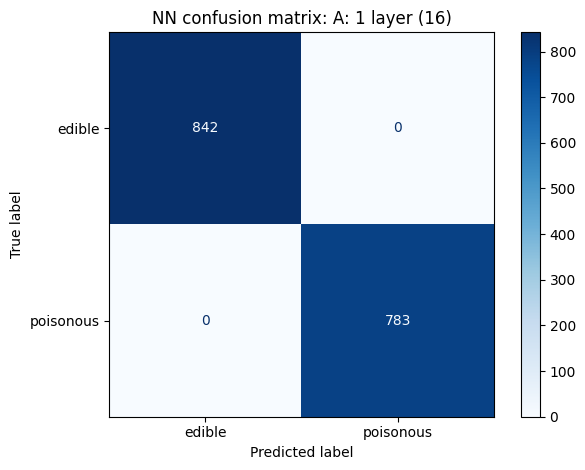

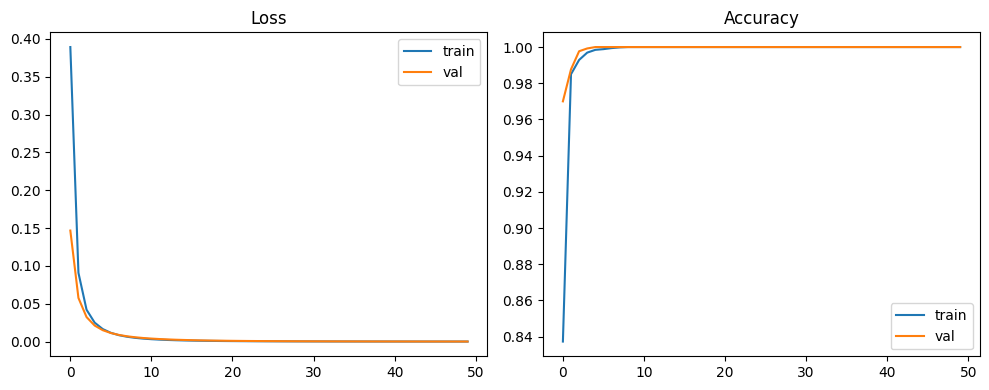

In [4]:
best_name = results.sort_values(['F1','ROC_AUC','Params'], ascending=[False,False,True]).iloc[0]['Model']
best = models[best_name]; print("Best:", best_name)
prob = best.predict(X_test, verbose=0).ravel(); pred = (prob>=0.5).astype(int)
print(classification_report(y_test, pred, target_names=['edible','poisonous']))
ConfusionMatrixDisplay(confusion_matrix(y_test,pred), display_labels=['edible','poisonous']).plot(cmap='Blues')
plt.title('NN confusion matrix: '+best_name); plt.tight_layout()
os.makedirs('../results/eda_visualizations', exist_ok=True)
plt.savefig('../results/eda_visualizations/M6_nn_confusion_matrix.png', dpi=150); plt.show()
h = histories[best_name].history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(h['loss'],label='train'); plt.plot(h['val_loss'],label='val'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2); plt.plot(h['accuracy'],label='train'); plt.plot(h['val_accuracy'],label='val'); plt.title('Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig('../results/eda_visualizations/M6_nn_training_curves.png', dpi=150); plt.show()

In [5]:
cfg = variants[best_name]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Xa = pd.concat([X_train, X_test]).reset_index(drop=True); ya = pd.concat([y_train, y_test]).reset_index(drop=True)
cv = []
for tr, va in skf.split(Xa, ya):
    m = build(**cfg)
    m.fit(Xa.iloc[tr], ya.iloc[tr], validation_split=0.2, epochs=50, batch_size=32, callbacks=[early], verbose=0)
    p = (m.predict(Xa.iloc[va], verbose=0).ravel()>=0.5).astype(int)
    cv.append(accuracy_score(ya.iloc[va], p))
print("CV accuracies:", np.round(cv,4), "| mean", round(np.mean(cv),4), "| std", round(np.std(cv),4))

CV accuracies: [0.9434 0.9532 0.9655 0.9569 0.9692] | mean 0.9577 | std 0.0092


In [6]:
os.makedirs('../results/outputs', exist_ok=True)
results.to_csv('../results/outputs/M6_nn_results.csv', index=False)
best.save('../results/outputs/M6_nn_best_model.keras')